In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("../")


In [2]:
#Importing Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

In [5]:
data_path = "data/"
model_performance_dir = "model_performance"
if not os.path.exists(model_performance_dir):
    os.makedirs(model_performance_dir)

In [6]:
models = [
    ("Linear Regression", LinearRegression()),###fits wrongly, doesn't fit weel the middle point
    ("Decision Tree Regression", DecisionTreeRegressor(max_depth=3, random_state=0)),### too simple, prone to overfitting
    ("Random Forest Regression", RandomForestRegressor(max_depth=3, random_state=0)),### fits worse the right lower corner, and lower edge (confirm)
    ("Gradient Boosting Regression", GradientBoostingRegressor(random_state=0)),###in agreement with random forest
    ("Kernel Ridge Regression", KernelRidge()),## ? also in agreement with random forest. check how it works
    ("Gaussian Process Regression", GaussianProcessRegressor(random_state=0)),###lowest edge/corner right cases cant predict
    ("Multilayer Perceptron Regression", MLPRegressor(hidden_layer_sizes = (1), random_state=0))##too little data?
]

In [12]:
select_cols=["rownum", "xA", "yA", "zA", "xC", "yC", "zC", "rA", "rB", "rC", "TF", "Eg", "duplicated"]
df = pd.read_csv(data_path+"prepared_data_Sona.csv")[select_cols]
df.head()
df.dropna(inplace=True)

In [13]:
df.isnull().sum()

rownum        0
xA            0
yA            0
zA            0
xC            0
yC            0
zC            0
rA            0
rB            0
rC            0
TF            0
Eg            0
duplicated    0
dtype: int64

In [14]:
train_cols = ["xA", "yA", "zA", "xC", "yC", "zC", "rA", "rB", "rC", "TF"]##,"rA"
target_col = "Eg"
X=df[train_cols]
y=df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(len(X_train), len(X_test))

92 24


In [15]:
###correcting the test set. all the tri-element cases should be in test
test_def = df[(df["xC"]!=0)&(df["yC"]!=0)&(df["xC"]+df["yC"]<1)]
X_train = X_train.drop(labels=test_def.index)
y_train = y_train.drop(labels=test_def.index)
X_test = pd.concat([X_test, test_def[train_cols]])
y_test = pd.concat([y_test, test_def[target_col]])
print(len(X_train), len(X_test))

92 24


Testing Linear Regression
Performance of  Linear Regression
Mean error for train set: 0.021216720245688953
Median error for train set: 0.014189006301038793
Mean error for validation set: 0.03132093985884859
Median error for validation set: 0.024279809044765198
Testing Decision Tree Regression
Performance of  Decision Tree Regression
Mean error for train set: 0.02369816821954512
Median error for train set: 0.02097649186256837
Mean error for validation set: 0.03556663736357766
Median error for validation set: 0.030414841439215218
Testing Random Forest Regression
Performance of  Random Forest Regression
Mean error for train set: 0.018032653523253683
Median error for train set: 0.01142176193606386
Mean error for validation set: 0.026592843344091874
Median error for validation set: 0.024919001019687005
Testing Gradient Boosting Regression
Performance of  Gradient Boosting Regression
Mean error for train set: 0.004484685306058963
Median error for train set: 0.002830259910651267
Mean error fo

/home/gosh/anaconda3/envs/sonne/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/gosh/anaconda3/envs/sonne/lib/python3.11/site-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


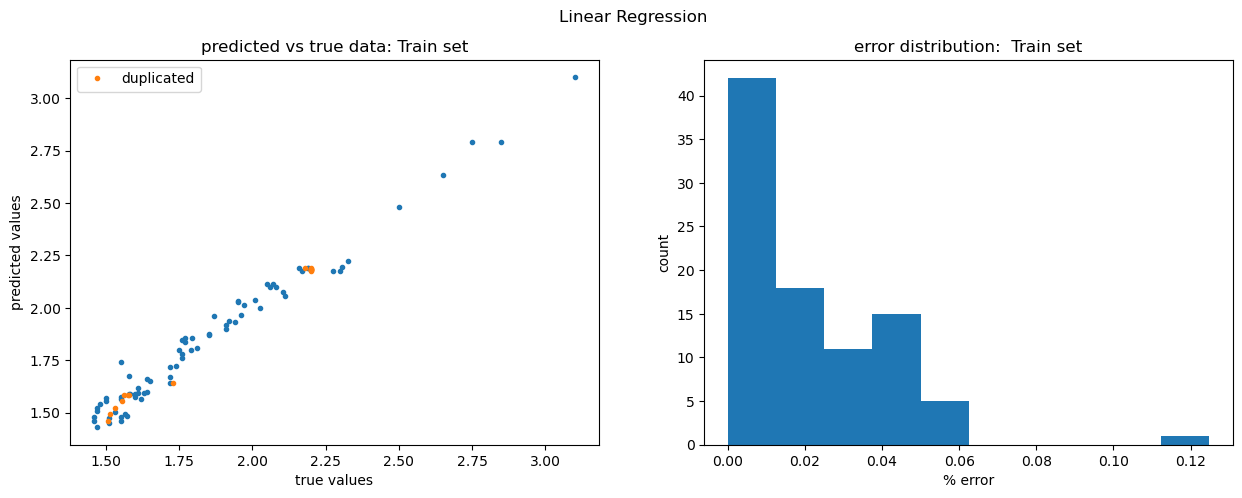

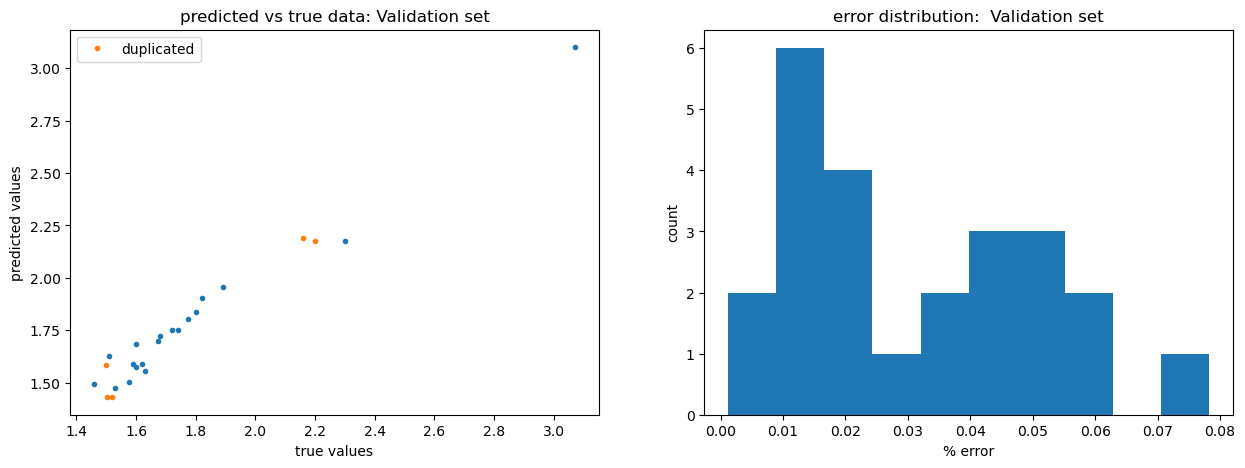

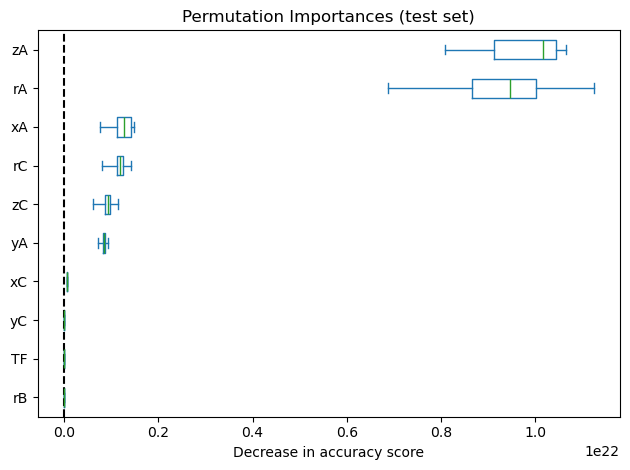

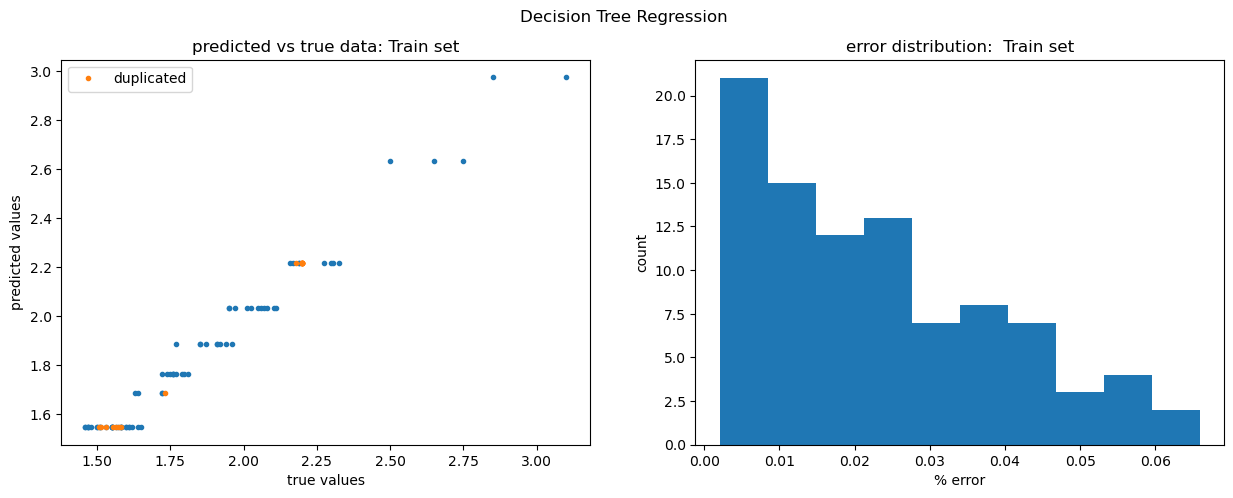

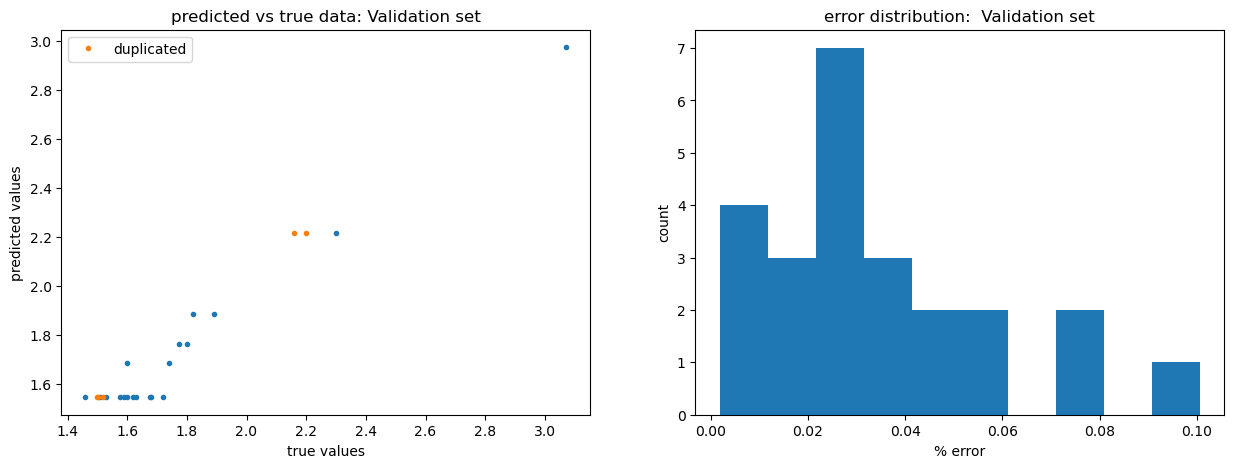

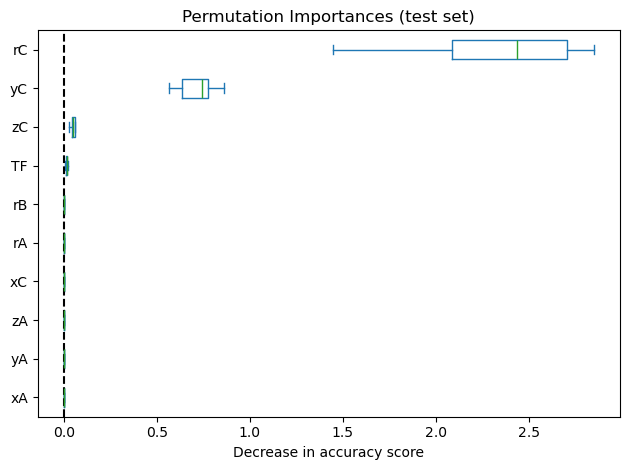

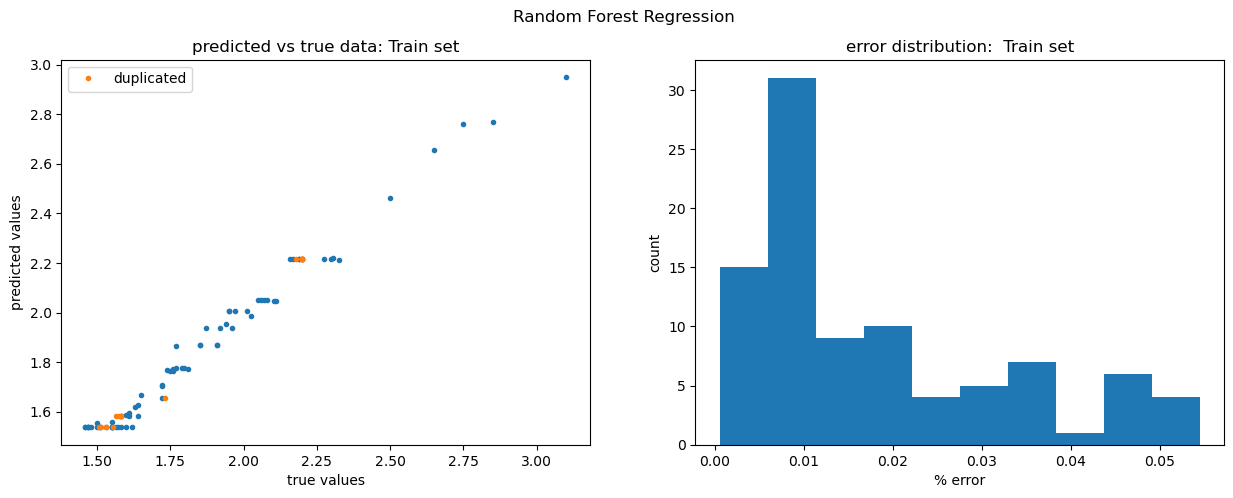

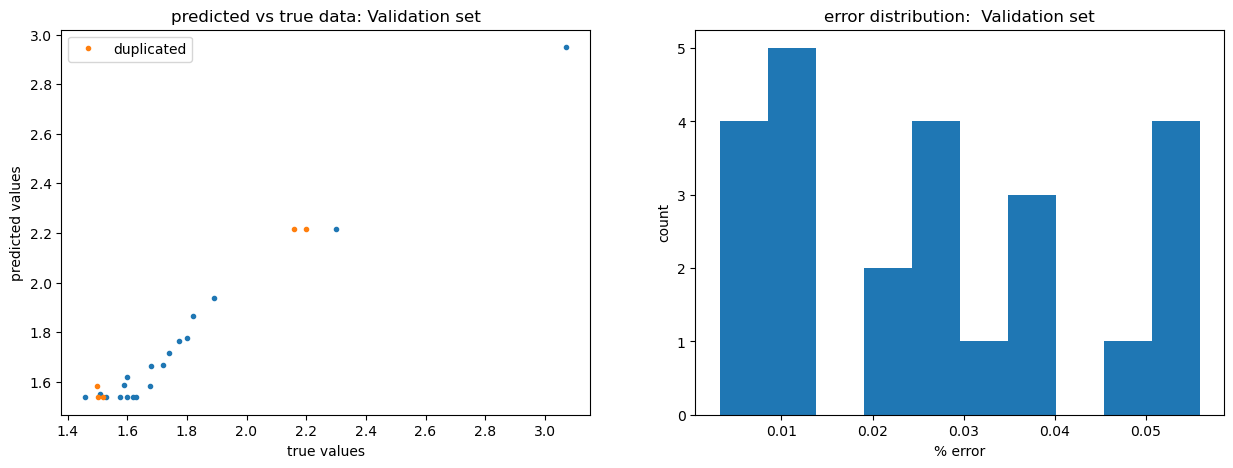

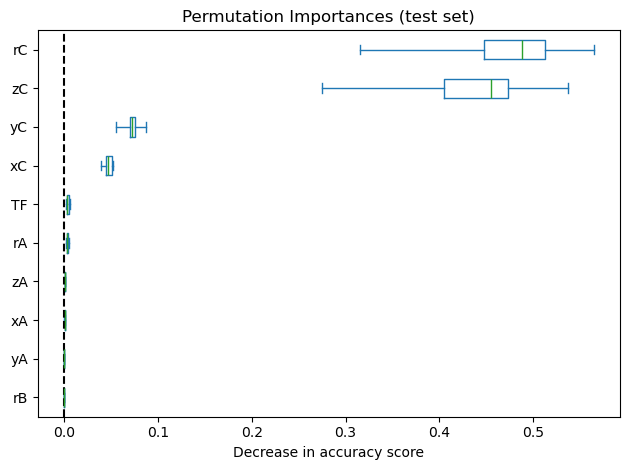

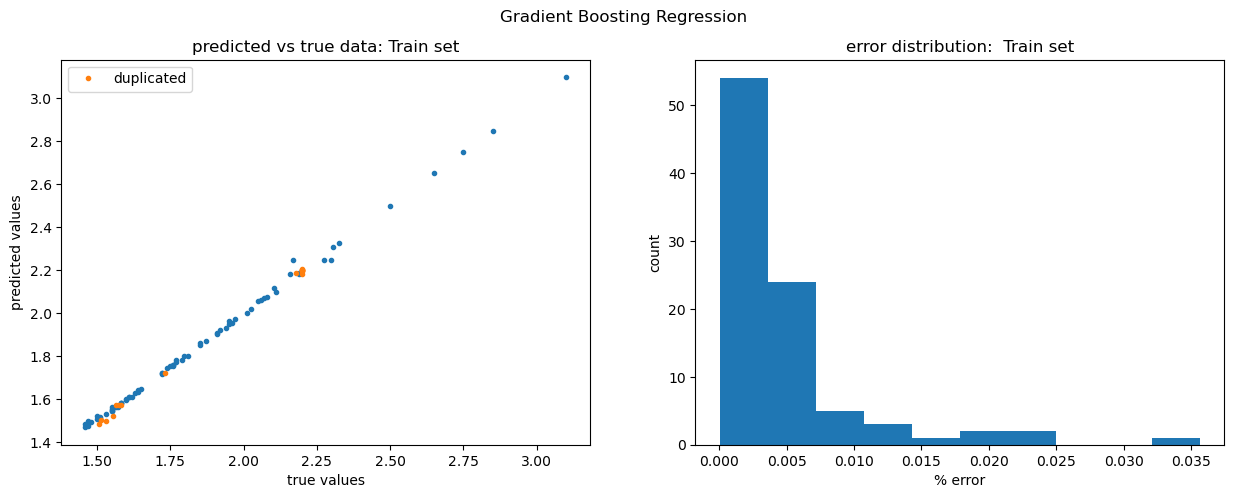

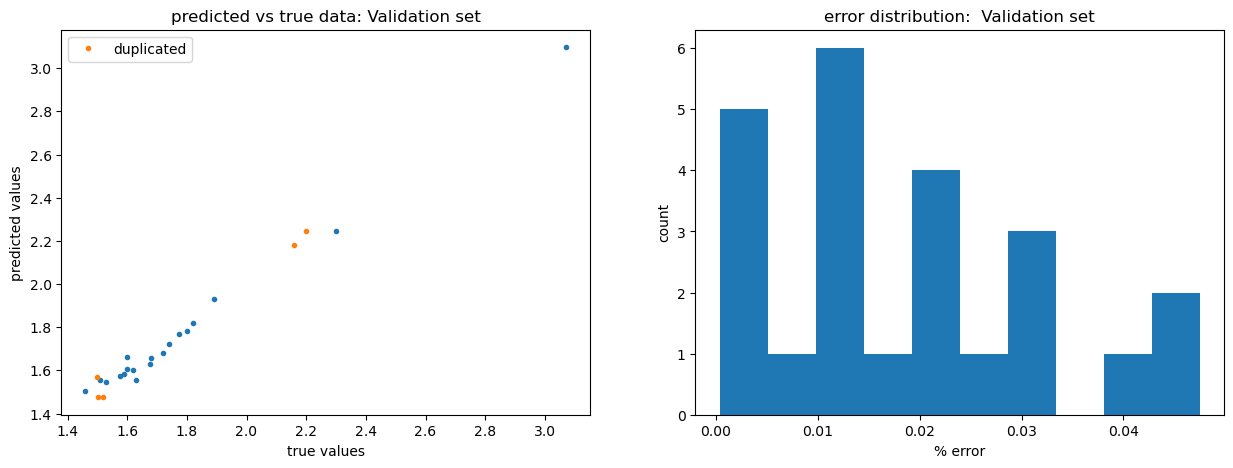

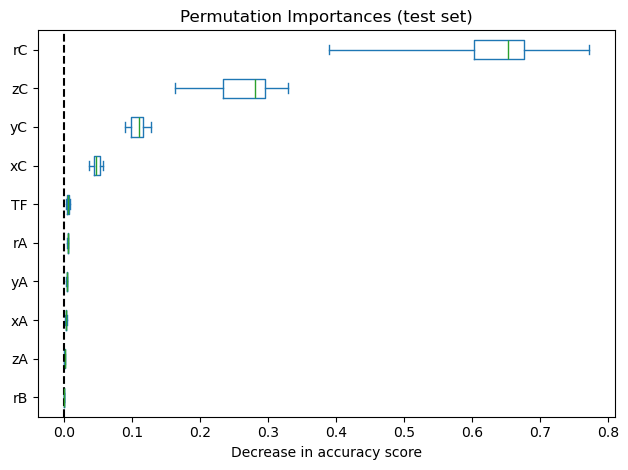

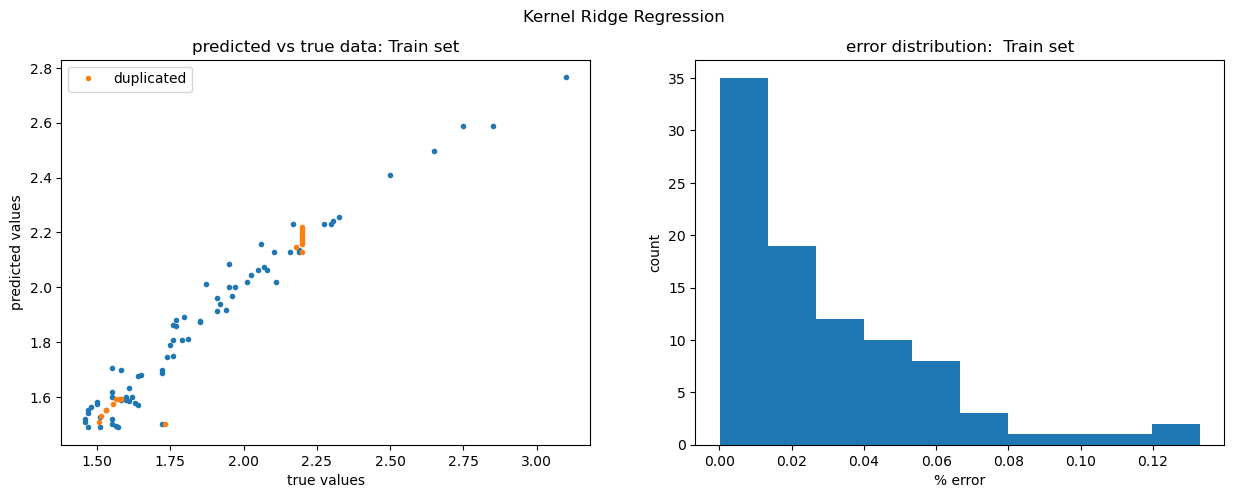

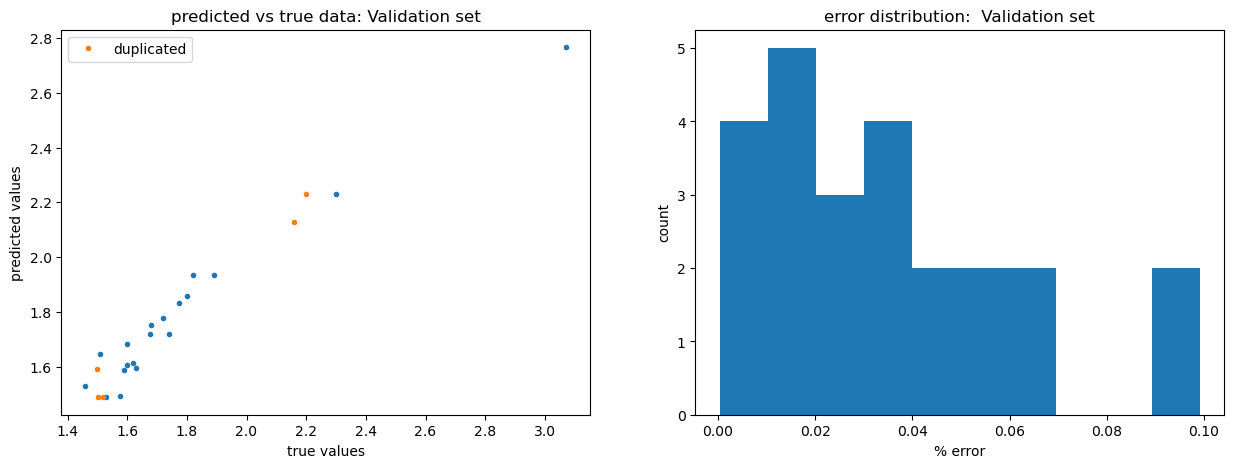

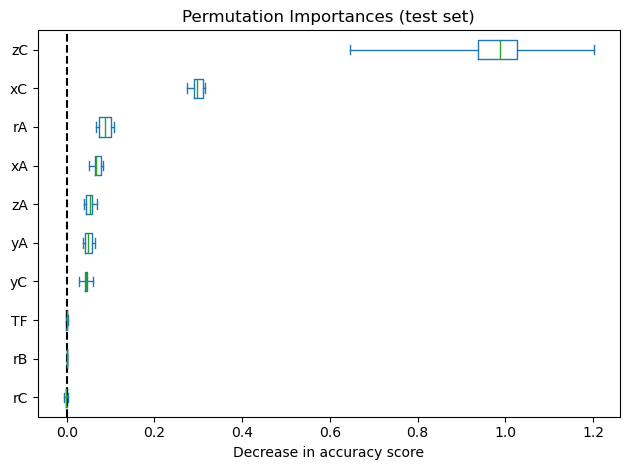

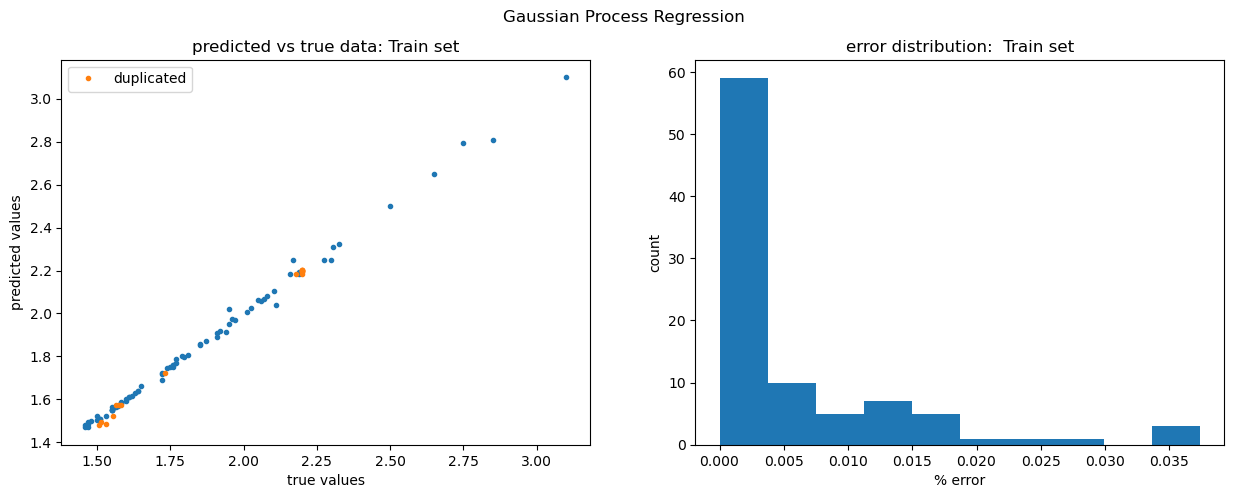

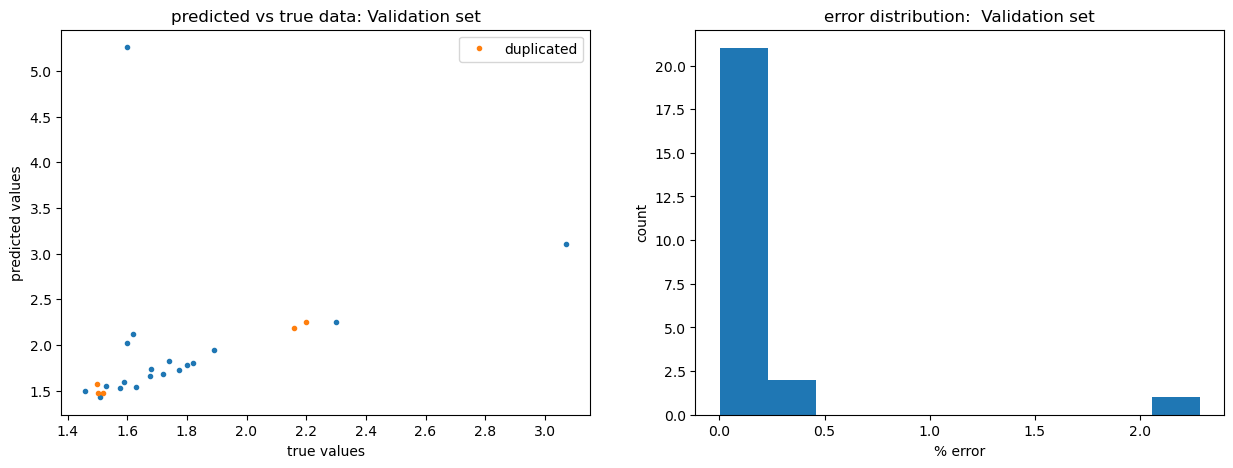

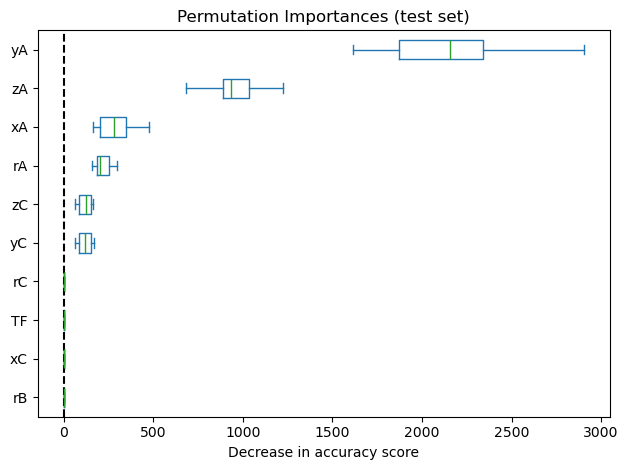

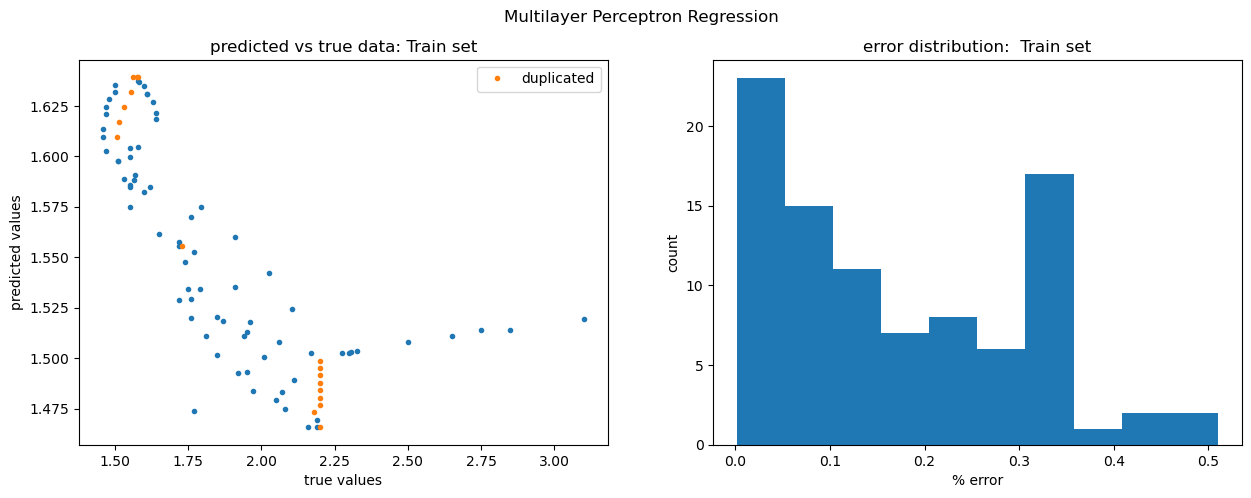

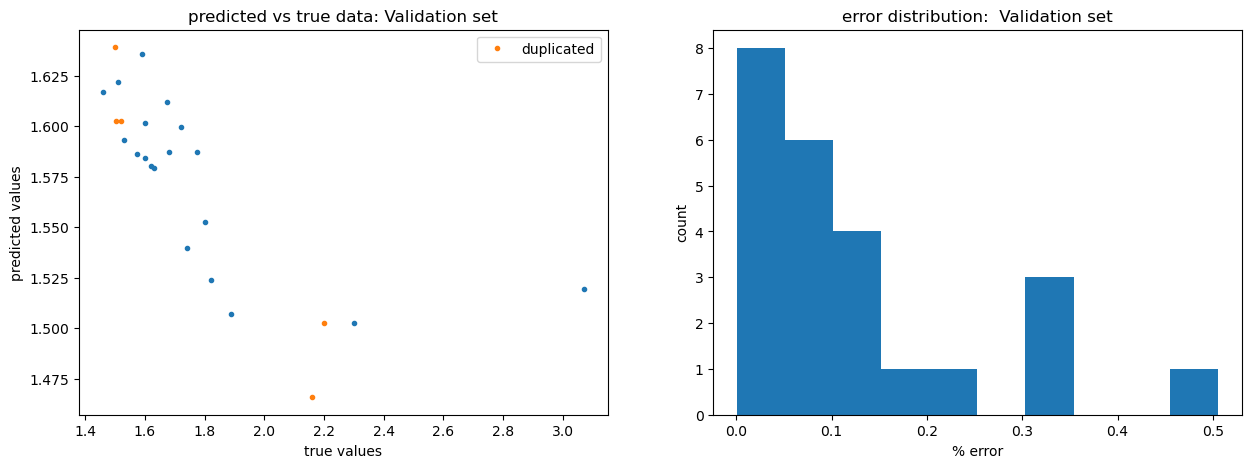

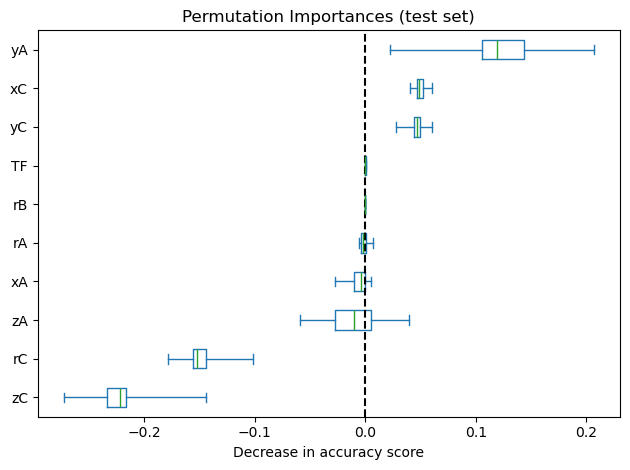

In [16]:
# Iterate over the models and evaluate their performance
for name, model in models:
    print(f"Testing {name}")

    # Create a subdirectory for the current model
    model_dir = os.path.join(model_performance_dir, name.replace(' ', '_'))
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    # Fit the model on the training data
    model.fit(X_train, y_train)
    ####################################
    ytr_pred = model.predict(X_train)
    # Make predictions on the testing data
    y_pred = model.predict(X_test)
    df.loc[y_test.index, "predicted"]=y_pred
    df.loc[y_test.index, "test"]=1
    df.loc[y_train.index, "predicted"]=ytr_pred
    df["error"]=abs(df["Eg"]-df["predicted"])/df["Eg"]
    #
    print("Performance of  {}".format(name))
    print("Mean error for train set: {}".format(df[df["test"]!=1]["error"].mean()))
    print("Median error for train set: {}".format(df[df["test"]!=1]["error"].median()))
    print("Mean error for validation set: {}".format(df[df["test"]==1]["error"].mean()))
    print("Median error for validation set: {}".format(df[df["test"]==1]["error"].median()))
    error_dict = {
        "train mean error" : df[df["test"]!=1]["error"].mean(),
        "train median error" : df[df["test"]!=1]["error"].median(),
        "test mean error" : df[df["test"]==1]["error"].mean(),
        "test median error" : df[df["test"]==1]["error"].median(),
        }
    # Create and write model information to a text file
    with open(os.path.join(model_dir, "performance.txt"), "w") as f:
        f.write(f"Model: {name}\n")
        f.write(json.dumps(error_dict))
    fig, ax = plt.subplots(1,2, figsize=(15, 5))
    plt.suptitle(name)
    ax[0].plot(df[(df["test"]!=1)&(df["duplicated"]!=1)]["Eg"], df[(df["test"]!=1)&(df["duplicated"]!=1)]["predicted"], ".")
    ax[0].plot(df[(df["test"]!=1)&(df["duplicated"]==1)]["Eg"], df[(df["test"]!=1)&(df["duplicated"]==1)]["predicted"], ".", label="duplicated")
    ax[0].set_xlabel("true values")
    ax[0].set_ylabel("predicted values")
    ax[0].set_title("predicted vs true data: Train set")
    ax[0].legend()
    ax[1].hist(df[df["test"]!=1]["error"])
    ax[1].set_xlabel("% error")
    ax[1].set_ylabel("count")
    ax[1].set_title("error distribution:  Train set")
    #
    plt.savefig(os.path.join(model_dir, "train_error.png"))
    ##plt.savefig(model_path+'train_error.png')
    fig, ax = plt.subplots(1,2, figsize=(15, 5))
    ax[0].plot(df[(df["test"]==1)&(df["duplicated"]!=1)]["Eg"], df[(df["test"]==1)&(df["duplicated"]!=1)]["predicted"], ".")
    ax[0].plot(df[(df["test"]==1)&(df["duplicated"]==1)]["Eg"], df[(df["test"]==1)&(df["duplicated"]==1)]["predicted"], ".", label="duplicated")
    ax[0].set_xlabel("true values")
    ax[0].set_ylabel("predicted values")
    ax[0].set_title("predicted vs true data: Validation set")
    ax[0].legend()
    ax[1].hist(df[df["test"]==1]["error"])
    ax[1].set_xlabel("% error")
    ax[1].set_ylabel("count")
    ax[1].set_title("error distribution:  Validation set")
    plt.savefig(os.path.join(model_dir, "val_error.png"))

    print("="*40)

    df[df["error"]>0.1].to_csv(os.path.join(model_dir,"anomalous_points.csv"))

    #####################
    result = permutation_importance(
    model, X_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)
    sorted_importances_idx = result.importances_mean.argsort()
    importances = pd.DataFrame(
        result.importances[sorted_importances_idx].T,
        columns=X.columns[sorted_importances_idx],
    )
    ax = importances.plot.box(vert=False, whis=10)
    ax.set_title("Permutation Importances (test set)")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in accuracy score")
    ax.figure.tight_layout()
    plt.savefig(os.path.join(model_dir, "importance.png"))

In [17]:
model.predict(X_test)

array([1.62178692, 1.50249242, 1.59306121, 1.60239725, 1.58720185,
       1.63912272, 1.58012323, 1.63578649, 1.52377159, 1.59949876,
       1.58605917, 1.5067754 , 1.60239725, 1.61708744, 1.57917411,
       1.51956001, 1.50249242, 1.58711736, 1.58408098, 1.60171472,
       1.46579705, 1.55245063, 1.53974051, 1.61179575])

In [18]:
df[df["predicted"]<-1]

,rownum,xA,yA,zA,xC,yC,zC,rA,rB,rC,TF,Eg,duplicated,predicted,test,error
